In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

In [2]:
abund_mass= pd.read_csv(r"C:\Users\LENOVO\Documents\PostGrad\BSc Hons\4ZOL509_Research\data\abundance_biomass.csv")
sieve = pd.read_csv(r"C:\Users\LENOVO\Documents\PostGrad\BSc Hons\4ZOL509_Research\data\sieve.csv")

In [3]:
# Preprocessing: Aggregate abundance & biomass per replicate/site/sample ===
summary = abund_mass.groupby(["site","replicate","sample", "month"]).agg(
    abundance=('prawn_id','count'),
    biomass=('dry_weight','sum')
).reset_index()


# Merge all into one dataset
merged = pd.merge(summary, sieve, on=["site","replicate","sample", "month"], how="left")

grain_cols = ["sieve_2um","sieve_1um","sieve_500um","sieve_250um","sieve_125um","sieve_63um","sieve_pan"]

In [4]:
X = merged[["abundance","biomass"] + grain_cols].fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

iso = IsolationForest(contamination=0.1, random_state=42)
merged["anomaly"] = iso.fit_predict(X_scaled)  # -1 = outlier

In [5]:
def plot_reg(x, y, xlabel, ylabel, ax, title, data, degree=2):
    # Drop NA values
    mask = ~data[x].isna() & ~data[y].isna()
    x_vals = data.loc[mask, x].values.reshape(-1, 1)
    y_vals = data.loc[mask, y].values

    # Linear regression
    slope, intercept, r_value, p_value, std_err = linregress(x_vals.flatten(), y_vals)
    
    # Polynomial regression
    model_poly = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model_poly.fit(x_vals, y_vals)
    
    # Random forest regression
    model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
    model_rf.fit(x_vals, y_vals)
    
    # Prediction range
    x_range = np.linspace(x_vals.min(), x_vals.max(), 100).reshape(-1, 1)
    y_pred_poly = model_poly.predict(x_range)
    y_pred_rf = model_rf.predict(x_range)
    
    # Scatter plot
    sns.regplot(x=x_vals, y=y_vals, ax=ax, scatter_kws={'s': 50}, label='Linear')
    
    # Plot fitted models
    ax.plot(x_range, y_pred_poly, color='darkorange', linewidth=2, label=f'Poly (deg {degree})')
    ax.plot(x_range, y_pred_rf, color='green', linewidth=2, label='Random Forest')
    
    sns.scatterplot(data=merged, x="abundance", y="biomass", hue="anomaly", palette={-1: "red", 1: "dodgerblue"}, ax=ax)
    
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    
    # Annotate with equation and R²
    reg_eq = f'Linear: y = {slope:.2f}x + {intercept:.2f}\n$R^2$ = {r_value**2:.3f}'
    ax.text(0.05, 0.95, reg_eq, transform=ax.transAxes, 
            verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7))
    
    ax.legend()

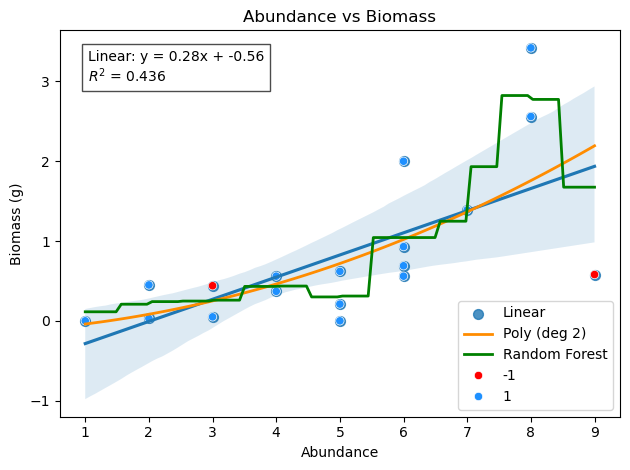

In [8]:
fig, axes = plt.subplots(1, 1)

plot_reg('abundance', 'biomass', 'Abundance', 'Biomass (g)', axes, 'Abundance vs Biomass', data=summary, degree=2)

plt.savefig(r"C:\Users\LENOVO\Documents\PostGrad\BSc Hons\4ZOL509_Research\fig\abundance_vs_biomass.png", dpi=500)
plt.tight_layout()
plt.show()